# Training Models

This is a jupyter note that contains code example of fourth chapter of the book.

You won't find here detailed explanation of the contents. This notebook contains **general info** and **code examples**.
See detailed notes about all conception on my cloud obsidian vault.

Importing packages...

In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import title

from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression

# The Normal Equation

Let's generate some linear data and plot it.

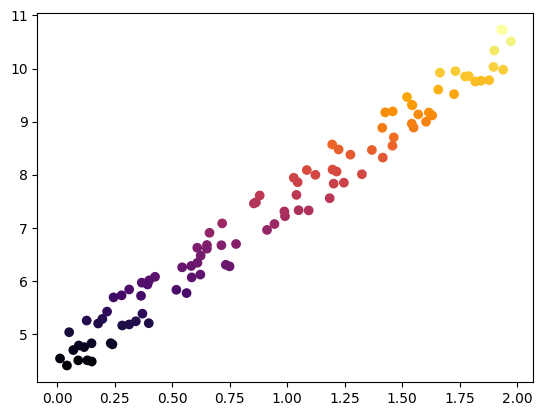

In [3]:
np.random.seed(42)

n = 100
X = 2 * np.random.rand(n, 1) # Column vector
y = 4 + 3 * X + np.random.rand(n, 1) # Column vector as well

plt.scatter(X, y, c=y, cmap="inferno")
plt.show()

Now, let's apply **The Normal Equation**, to get first $\theta$ value for linear regression model.

 > As we know, $x0$ feature at the bias $\theta$ is always equals 1, that's why we need to add dummy feature to each instance that equals to 1

In [4]:
X_d = add_dummy_feature(X=X)
X_d[:3]

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788]])

Now, we can apply our **Normal Equation**.
Formula:


In [5]:
if not np.linalg.det(X_d.T @ X_d) <= 0:
    theta_0 = np.linalg.inv(X_d.T @ X_d) @ X_d.T @ y
    print(theta_0)
else:
    print("Matrix determinant is zero, could not inverse it")

[[4.51359766]
 [2.98323418]]


We got our parameters, now we can train our simple **Linear Regression** model!

In [6]:
X_new = np.array([[0], [2]])
X_new_d = add_dummy_feature(X=X_new)
y_predictions = X_new_d @ theta_0
y_predictions

array([[ 4.51359766],
       [10.48006601]])

Now, when we know 2 predictions, we can plot a line through two predictions dots. That is our **Linear Regression Predictions**.

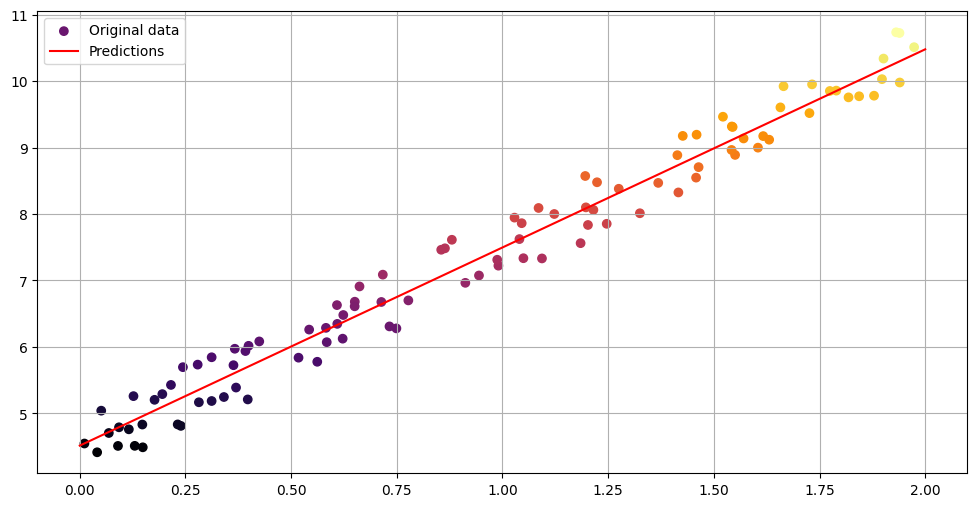

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

plt.scatter(X, y, c=y, cmap="inferno", label="Original data")
plt.plot(X_new, y_predictions, color="red", label="Predictions")
plt.grid(True)
plt.legend()
plt.show()

Let's try to use **SKlearn** Linear Regression model, the approach is relatively straightforward.

In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_

(array([4.51359766]), array([[2.98323418]]))

As you can see, the bias and $\theta$ parameters are the same as ours!

In [9]:
lin_reg.predict(X_new)

array([[ 4.51359766],
       [10.48006601]])

Since The Normal Equation isn't universal, because we can't take inverted matrix when the matrix determinant is 0 and the matrix isn't squared. All model are using **The Least Squares Approach**. Formula:

Where + is pseudoinverse matrix. This matrix is computed by using **SVD** _(Singular Value Decomposition)_.

In [10]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_d, y, rcond=1e-6)
theta_best_svd

array([[4.51359766],
       [2.98323418]])

Using the formula, we can manually compute the parameters.

In [11]:
np.linalg.pinv(X_d) @ y

array([[4.51359766],
       [2.98323418]])

The Time complexity of the **Normal Equation** is about $O(n^{2.4})$ to $O(n^3)$, while the SVD approach is about $O(n^2)$. The prediction time is linear.

# Gradient Descent

Gradient Descent is another way to train Linear Regression and an optimal approach to optimize and find optimal solution to wide range of problems.

In [24]:
eta = 0.1
n_epochs = 1000
m = len(X_d)

np.random.seed(42)
theta = np.random.rand(2, 1)

for _ in range(n_epochs):
    gradients = (2 / m) * X_d.T @ (X_d @ theta - y)
    theta = theta - eta * gradients

theta

array([[4.51359766],
       [2.98323418]])

Exactly what out **Normal Equation** found! Now, we can plot each training step, to see how parameters $\eta$ and **n_epoch** are influencing on our linear regression line.

> Each iteration over training set called **Epoch**

In [85]:
def plot_gradient_descent(eta: int, n_epochs: int, X: np.array, best_theta: np.array = None):
    thetas = []
    theta = np.random.rand(2, 1)

    for _ in range(n_epochs):
        gradients = (2 / m) * X_d.T @ (X_d @ theta - y)
        theta = theta - eta * gradients
        thetas.append(theta)

    X_model_line = np.array([[0], [2]])

    for i, theta in enumerate(thetas):
        predictions = add_dummy_feature(X=X_model_line) @ theta

        plt.plot(X_model_line, predictions, color="blue", alpha=1/n_epochs*i)

    if best_theta is not None:
        plt.plot(X_model_line, add_dummy_feature(X=X_model_line) @ best_theta, color="red")

    plt.show()

Now we can plot our gradient descent process and see how our hyperparameters $\eta$ and **n_epochs** affect $\theta$ parameters selection.

If learning step is too high - we just jump over to global MSE minimum.

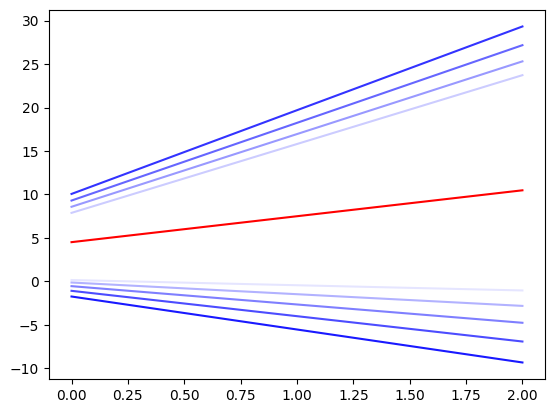

In [91]:
plot_gradient_descent(0.5, 10, X_d, best_theta=theta)


If we set reasonable learning step - our thetas would be near the global minimum of the MSE.

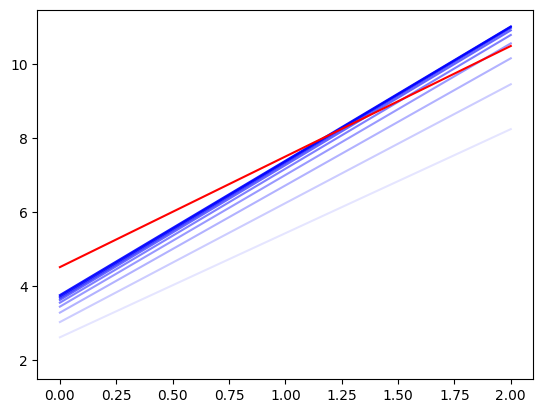

In [96]:
plot_gradient_descent(0.1, 10, X_d, best_theta=theta)

At to small learning step - we might not reach the MSE minimum.

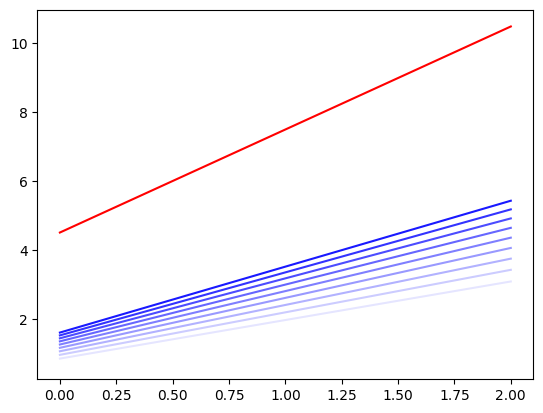

In [93]:
plot_gradient_descent(0.01, 10, X_d, best_theta=theta)